# Tracing Global Warming — Exploratory Data Analysis
**Mid-Deliverable Submission**

## 1. Theme
The central theme of this project is **Tracing the Physical Reality of Global Warming**. 
We aim to construct a data-backed foundation for a narrative-driven climate visualization. We trace the causal chain from observed warming, through attribution (human vs. natural forcings), to the physical consequences observed in Earth's systems (oceans and cryosphere), before closing the loop with the human emissions source signal.

## 2. Datasets Used
This project utilizes a suite of time-series datasets:

1. **Global Temperature Anomaly** (`observed.csv`): Annual global mean temperature anomalies (1880–2014).
2. **Climate Forcings** (`forcings.csv`): Human and natural radiative forcings in absolute Kelvin (1850–2005).
3. **Natural Variability Baseline** (`piControl.csv`): 851 years of simulated pre-industrial temperature variability (Kelvin).
4. **Atmospheric Greenhouse Gases** (`CO2monthlyavg.txt`, `CH4monthlyavg.txt`): NOAA ESRL monthly mean observations from Mauna Loa.
5. **Global Mean Sea Level** (`NASA_SSH_GMSL_INDICATOR.txt`): NASA satellite altimetry tracking sea level rise.
6. **Sea Ice Index** (`Sea_Ice_Index_Monthly_Data_by_Year_G02135_v4.0.xlsx`): NSIDC monthly Arctic sea ice extent.
7. **CO2 Emissions** (`co2-emissions-fossil-land.csv`): Global Carbon Project annual emissions.

## 3. Overall Questions, Motivations, and Citations

**Question 1: Are current warming trends statistically distinct from natural historical climate variability?**
*   **Motivation**: A common public misunderstanding is that modern warming is a natural cycle. To firmly establish human causality, we must first demonstrate that modern warming breaches the boundaries of pre-industrial natural variance.
*   **Citation**: IPCC, 2021: Climate Change 2021: The Physical Science Basis. Contribution of Working Group I to the Sixth Assessment Report.

**Question 2: How do the physical consequences of warming manifest in the oceans and cryosphere?**
*   **Motivation**: Temperature is an abstract metric. Translating warming into physical impacts—like the thermal expansion of oceans (sea level rise) and the melting of polar ice—provides visceral, measurable evidence of a shifting Earth system. 
*   **Citation**: NASA Global Climate Change: Vital Signs of the Planet; NSIDC Sea Ice Index.

**Question 3: What is the relationship between the human emissions "flow" and the atmospheric concentration "stock"?**
*   **Motivation**: Understanding the climate crisis requires distinguishing between what we put into the system annually (emissions) and what accumulates over time (concentrations). The flow-stock relationship is critical to the causality story.
*   **Citation**: Global Carbon Project (2023) - Carbon budget and emissions tracking; Friedlingstein et al., Earth System Science Data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from scipy import stats
import warnings
import os
warnings.filterwarnings('ignore')

# ---------------------------------------------------------
# PATH CONSTANTS
# Define dataset paths here for portability
# ---------------------------------------------------------
PATH_OBSERVED = 'observed.csv'
PATH_FORCINGS = 'forcings.csv'
PATH_PICONTROL = 'piControl.csv'
PATH_CO2 = 'CO2monthlyavg.txt'
PATH_CH4 = 'CH4monthlyavg.txt'
PATH_EMISSIONS = 'co2-emissions-fossil-land.csv'
PATH_SEA_ICE = 'Sea_Ice_Index_Monthly_Data_by_Year_G02135_v4.0.xlsx'
# Note: Use a clean variable for the absolute path of the NASA dataset
PATH_SEA_LEVEL = r'c:\NASA\sea_level_data\NASA_SSH_GMSL_INDICATOR.txt'

# Colors
plt.style.use('seaborn-v0_8-whitegrid')
C_BLUE = '#1f77b4'
C_RED = '#d62728'
C_GRAY = '#7f7f7f'
C_ORANGE = '#ff7f0e'
C_BLACK = '#2c3e50'

## 4. Phase 1: Dataset Overview & Structural Audit
In this section, we ingest, clean, and explore the structures of all relevant datasets.

### Map Visualization Note
The datasets analyzed here are overwhelmingly **temporal scalar aggregates** (e.g., global mean temperature, global sea level, pan-Arctic ice extent, or Mauna Loa point observations). As such, map visualizations are not applicable to the core physics tracking. 
However, the emissions dataset (`co2-emissions-fossil-land.csv`) contains ISO country codes. To fulfill the geographic visualization requirement, we will plot a choropleth map of the emissions footprint before proceeding to the global narrative.

In [2]:
# Helper for structural audit
def audit(df, name):
    print(f"=== {name} ===")
    print(f"Shape: {df.shape}")
    print(f"Missing Values: {df.isna().sum().sum()}")
    print("Columns:", df.columns.tolist())
    print("-" * 30)

### 4.1 Temperature, Forcings, and Baseline
We load the observed temperature anomalies, forcings, and piControl simulation, standardizing column names immediately.

In [3]:
# 1. Observed Temperature
observed = pd.read_csv(PATH_OBSERVED)
# Standardize columns
if 'Annual_Mean' in observed.columns:
    observed.rename(columns={'Annual_Mean': 'temp_anomaly'}, inplace=True)
elif 'Data' in observed.columns: # fallback if 'Data' exists
    observed.rename(columns={'Data': 'temp_anomaly'}, inplace=True)
if 'Year' in observed.columns: observed.rename(columns={'Year': 'year'}, inplace=True)

# 2. Climate Forcings
forcings = pd.read_csv(PATH_FORCINGS)
# Standardize human / natural / all forcings
col_map = {'Year': 'year', 'All forcings': 'all_forcings', 'Human': 'human', 'Natural': 'natural'}
forcings.rename(columns=col_map, inplace=True)

# 3. piControl Baseline
picontrol = pd.read_csv(PATH_PICONTROL)
# Standardize columns
picontrol.columns = ['year', 'temp_k']

audit(observed, 'Observed Temp')
audit(forcings, 'Forcings')
audit(picontrol, 'piControl baseline')

=== Observed Temp ===
Shape: (135, 3)
Missing Values: 4
Columns: ['year', 'temp_anomaly', '5-year_Mean']
------------------------------
=== Forcings ===
Shape: (156, 11)
Missing Values: 0
Columns: ['year', 'all_forcings', 'human', 'natural', 'Anthropogenic tropospheric aerosol', 'Greenhouse gases', 'Land use', 'Orbital changes', 'Ozone', 'Solar', 'Volcanic']
------------------------------
=== piControl baseline ===
Shape: (850, 2)
Missing Values: 0
Columns: ['year', 'temp_k']
------------------------------


### 4.2 Atmospheric Greenhouse Gases (CO2 & CH4)
The NOAA `.txt` datasets contain complex metadata and non-numeric rows. We write a robust parser to safely extract the time and concentration variables.

In [4]:
def parse_noaa_robust(filepath, value_col_idx):
    '''
    Robustly parses NOAA text files containing a mix of metadata, string headers,
    missing value sentinels (-999.99), and data.
    Assumes: token 1 = year, token 2 = month, token [value_col_idx] = value.
    '''
    data = []
    if not os.path.exists(filepath):
        print(f"Warning: {filepath} not found.")
        return pd.DataFrame()
        
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            # Skip comments and empty lines
            if not line or line.startswith('#'): continue
            
            parts = line.split()
            # Only process if we have enough tokens
            if len(parts) <= value_col_idx: continue
            
            try:
                # Year and month are assumed to be at index 1 and 2 in these files
                # (Index 0 is usually site_code like 'MLO')
                year = float(parts[1])
                month = float(parts[2])
                val = float(parts[value_col_idx])
                
                # Filter missing value sentinels
                if val == -999.99: 
                    val = np.nan
                
                data.append({'year': year, 'month': month, 'value': val})
            except ValueError:
                # If parsing fails (e.g. string header row like 'site_code year...'), skip
                continue
                
    return pd.DataFrame(data).dropna()

co2 = parse_noaa_robust(PATH_CO2, value_col_idx=10) # 10 is usually the value column in this specific MLO format
ch4 = parse_noaa_robust(PATH_CH4, value_col_idx=10)

if not co2.empty:
    co2.rename(columns={'value': 'co2_ppm'}, inplace=True)
    audit(co2, 'CO2 Monthly (Mauna Loa)')
if not ch4.empty:
    ch4.rename(columns={'value': 'ch4_ppb'}, inplace=True)
    audit(ch4, 'CH4 Monthly (Mauna Loa)')


=== CO2 Monthly (Mauna Loa) ===
Shape: (600, 3)
Missing Values: 0
Columns: ['year', 'month', 'co2_ppm']
------------------------------
=== CH4 Monthly (Mauna Loa) ===
Shape: (453, 3)
Missing Values: 0
Columns: ['year', 'month', 'ch4_ppb']
------------------------------


### 4.3 Sea Level, Sea Ice, and Emissions
We apply robust extraction techniques for the final three datasets.

In [14]:
# Sea Level
def load_sea_level(path):
    if not os.path.exists(path): return pd.DataFrame()
    lines = [L for L in open(path, 'r', encoding='utf-8') if not L.startswith('HDR')]
    rows = [list(map(float, L.split())) for L in lines if L.strip() and not L.startswith('H')]
    df = pd.DataFrame(rows)
    if len(df.columns) >= 3:
        df = df.iloc[:, [0, 1, 2]].copy()
        df.columns = ['decimal_year', 'gmsl_cm', 'gmsl_smooth_cm']
        # Drop large IEEE fill values
        df = df[df['gmsl_cm'] < 1000]
    return df

gmsl = load_sea_level(PATH_SEA_LEVEL)
if gmsl.empty:
    print('  Sea level data not found — skipping sea level chart. Add NASA GMSL file to run this section.')
else:
    print(f'  Sea level loaded: {len(gmsl)} rows, {gmsl["decimal_year"].min():.1f} – {gmsl["decimal_year"].max():.1f}')
    audit(gmsl, 'NASA Sea Level')

# Sea Ice
if os.path.exists(PATH_SEA_ICE):
    xl = pd.ExcelFile(PATH_SEA_ICE)
    # Check sheet names robustly
    if 'NH-Extent' in xl.sheet_names:
        nh_wide = xl.parse('NH-Extent', header=None, skiprows=1)
        months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
        nh_wide.columns = ['year'] + months + ['_spacer', 'Annual']
        nh_wide.drop(columns=['_spacer'], inplace=True)
        nh_wide['year'] = pd.to_numeric(nh_wide['year'], errors='coerce')
        nh_wide = nh_wide[(nh_wide['year'] >= 1979) & (nh_wide['year'] <= 2023)].copy()
        nh_long = nh_wide.melt(id_vars=['year','Annual'], value_vars=months, var_name='month', value_name='extent')
        print(f' Sea ice loaded: {len(nh_long)} records.')
        audit(nh_long, 'Arctic Sea Ice')
else:
    print('  Sea ice data not found — skipping sea ice chart. Add NSIDC Excel file to run this section.')

# Emissions
emissions = pd.read_csv(PATH_EMISSIONS)
audit(emissions, 'CO2 Emissions')


  Sea level loaded: 1723 rows, 1993.0 – 2026.2
=== NASA Sea Level ===
Shape: (1723, 3)
Missing Values: 0
Columns: ['decimal_year', 'gmsl_cm', 'gmsl_smooth_cm']
------------------------------
 Sea ice loaded: 540 records.
=== Arctic Sea Ice ===
Shape: (540, 4)
Missing Values: 2
Columns: ['year', 'Annual', 'month', 'extent']
------------------------------
=== CO2 Emissions ===
Shape: (40979, 5)
Missing Values: 21942
Columns: ['Entity', 'Code', 'Year', 'Fossil fuels and industry', 'Land-use change']
------------------------------


### Geographic Overview: Top Emitters in 2022
Addressing the map visualization rule using the geographical entities within the emissions data.

In [6]:
if not emissions.empty:
    # Use most recent widely complete year
    map_df = emissions[(emissions['Year'] == 2022) & emissions['Code'].notna()].copy()
    if 'Fossil fuels and industry' in map_df.columns:
        map_df['Fossil_Gt'] = map_df['Fossil fuels and industry'] / 1e9
        
        fig = px.choropleth(map_df, locations="Code", color="Fossil_Gt",
                            hover_name="Entity", color_continuous_scale=px.colors.sequential.OrRd,
                            title="Global Carbon Footprint: Fossil CO2 Emissions by Country (2022, GtCO2)")
        fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0})
        fig.show()

## 5. Phase 2: Question-Driven Exploratory Analysis
We transition from raw data inspection to refining visualizations that specifically address our overall questions.

### Question 1: Are current warming trends statistically distinct from natural historical climate variability?
We visualize the `piControl` dataset (simulating natural variability over 851 years) and set it as an expected envelope. Then, we plot the observed modern warming record against this envelope. We follow up by reviewing radiative forcings.

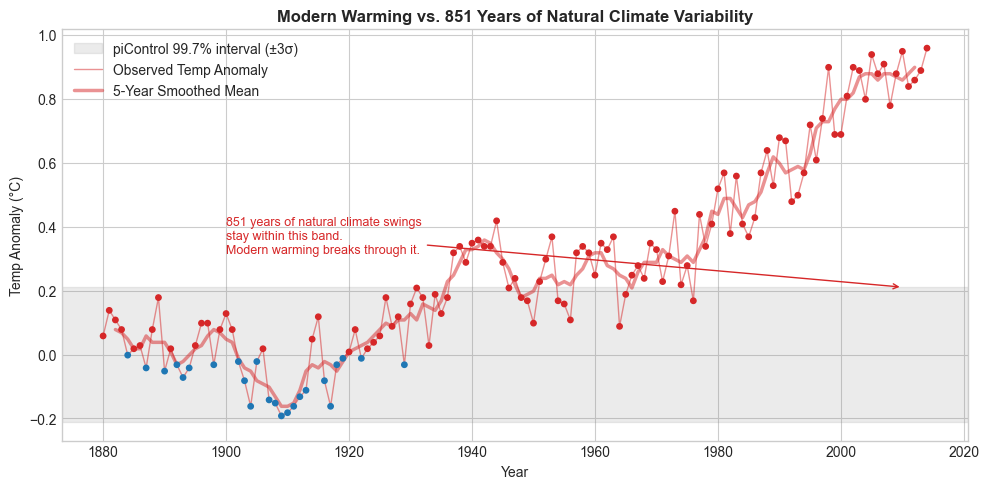

Max observed anomaly: 0.96°C
Pre-industrial 3σ envelope: ±0.21°C


In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

# 1. Plot piControl Statistical Bounds
pic_mean = picontrol['temp_k'].mean()
pic_std = picontrol['temp_k'].std()
# Create 3-sigma shading bounds representing 99.7% of natural variation
ax.axhspan(-pic_std*3, pic_std*3, color=C_GRAY, alpha=0.15, label='piControl 99.7% interval (±3σ)')

# 2. Normalize and Plot Observed Data
# Align zero to early pre-industrial proxy period (1880-1910)
baseline_val = observed[(observed['year'] >= 1880) & (observed['year'] <= 1910)]['temp_anomaly'].mean()
obs_norm = observed['temp_anomaly'] - baseline_val

# Dynamic coloring for observed anomaly dots
colors = [C_BLUE if val < 0 else C_RED for val in obs_norm]
ax.plot(observed['year'], obs_norm, color=C_RED, lw=1, alpha=0.5, label='Observed Temp Anomaly')
ax.scatter(observed['year'], obs_norm, color=colors, s=15, zorder=5)

ax.plot(observed['year'], observed['5-year_Mean'] - baseline_val, color=C_RED, lw=2.5, alpha=0.5, label='5-Year Smoothed Mean')
ax.annotate('851 years of natural climate swings\nstay within this band.\nModern warming breaks through it.', xy=(2010, pic_std*3), xytext=(1900, pic_std*4.5), arrowprops=dict(arrowstyle='->', color=C_RED), fontsize=9, color=C_RED)
ax.set_title("Modern Warming vs. 851 Years of Natural Climate Variability", fontweight='bold')
ax.set_ylabel("Temp Anomaly (°C)")
ax.set_xlabel("Year")
ax.legend()
plt.tight_layout(); plt.show()

print(f"Max observed anomaly: {obs_norm.max():.2f}°C")
print(f"Pre-industrial 3σ envelope: ±{pic_std*3:.2f}°C")

### Complementary View: Global Warming Stripes
To visceralize the observed temperature record mapped above, we can strip away axes and trend lines to create a 'barcode' of planetary heat. Each stripe represents the global average temperature of a single year. Blue bands indicate years cooler than the historical average, while red bands indicate warmer years. The intense concentration of dark red on the right edge is the visual analogue of the modern warming trend.

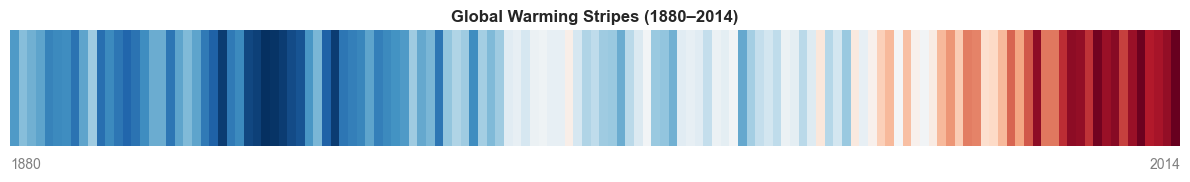

In [8]:
fig, ax = plt.subplots(figsize=(12, 2))

# We use the observed dataset. Normalize the data around the 1901-2000 average if possible, or simple baseline.
obs_stripes = observed.dropna(subset=['temp_anomaly'])
stripes_data = obs_stripes['temp_anomaly'].values.reshape(1, -1)

# Use a diverging colormap: blue for cold, red for hot
cmap = plt.get_cmap('RdBu_r')
ax.imshow(stripes_data, cmap=cmap, aspect='auto',
          extent=[obs_stripes['year'].min(), obs_stripes['year'].max(), 0, 1])

ax.set_axis_off()
plt.title('Global Warming Stripes (1880–2014)', fontweight='bold', fontsize=12)
plt.text(obs_stripes['year'].min(), -0.2, str(int(obs_stripes['year'].min())), ha='left', color=C_GRAY)
plt.text(obs_stripes['year'].max(), -0.2, str(int(obs_stripes['year'].max())), ha='right', color=C_GRAY)
plt.tight_layout()
plt.show()

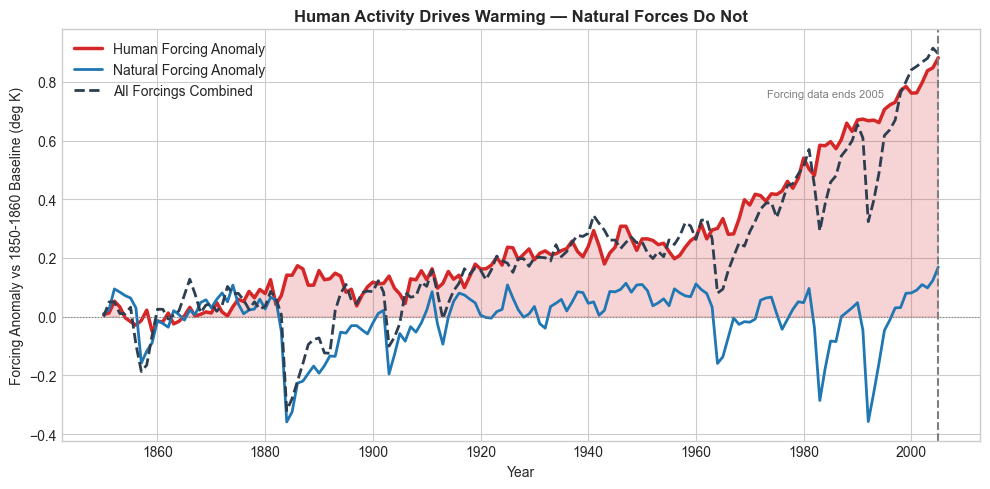

In [9]:
# Forcings attribution chart
# Data is absolute Kelvin -- subtract 1850-1860 baseline to reveal anomaly divergence
if 'human' in forcings.columns and 'natural' in forcings.columns:
    baseline = forcings[forcings['year'] <= 1860]
    base_human = baseline['human'].mean()
    base_natural = baseline['natural'].mean()

    human_anom = forcings['human'] - base_human
    natural_anom = forcings['natural'] - base_natural

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.fill_between(forcings['year'], human_anom, 0,
                    where=(human_anom > 0), color=C_RED, alpha=0.2)
    ax.plot(forcings['year'], human_anom, color=C_RED, lw=2.5,
            label='Human Forcing Anomaly')
    ax.plot(forcings['year'], natural_anom, color=C_BLUE, lw=2,
            label='Natural Forcing Anomaly')

    if 'all_forcings' in forcings.columns:
        all_anom = forcings['all_forcings'] - forcings['all_forcings'].iloc[0]
        ax.plot(forcings['year'], all_anom, color=C_BLACK, lw=2,
                linestyle='--', label='All Forcings Combined')

    ax.axhline(0, color=C_GRAY, lw=0.8, linestyle=':')
    ax.axvline(2005, color=C_GRAY, linestyle='--', lw=1.5)
    ymax = float(human_anom.max())
    ax.text(1995, ymax * 0.85, 'Forcing data ends 2005',
            fontsize=8, color=C_GRAY, ha='right')

    ax.set_title('Human Activity Drives Warming — Natural Forces Do Not',
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('Forcing Anomaly vs 1850-1860 Baseline (deg K)')
    ax.set_xlabel('Year')
    ax.legend()
    plt.tight_layout()
    plt.show()


*Analysis & Refinement*: The modern temperature trend thoroughly breaches the statistical boundaries of historical natural variation (the 3σ envelope). Furthermore, natural radiative forcing is completely flat long-term; the upward temperature trajectory perfectly aligns with the rise in human-produced forcing. The strong alignment is consistent with an anthropogenic mechanism driving warming.

Note: Radiative forcing data available through 2005. The observed temperature record continues beyond this window, consistent with the ongoing human forcing trend.

### Question 2: How do the physical consequences of warming manifest in the oceans and cryosphere?
We synthesize sea level rise (representing oceanic volume expansion and ice melt additions) and Arctic September sea ice extent (representing cryosphere degradation).

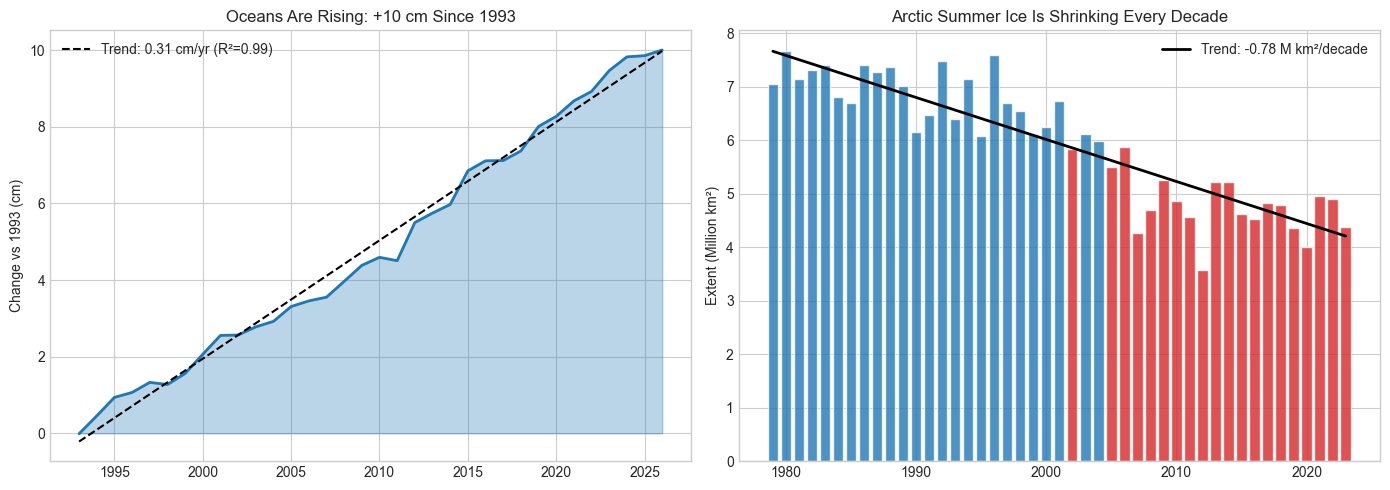

In [10]:
if not gmsl.empty and 'nh_long' in locals() and not nh_long.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 2a. Ocean Response: Global Mean Sea Level Rise
    gmsl['year_int'] = gmsl['decimal_year'].astype(int)
    gmsl_annual = gmsl.groupby('year_int')['gmsl_smooth_cm'].mean()
    
    # Linear trend
    s_sl, i_sl, r_sl, _, _ = stats.linregress(gmsl_annual.index, gmsl_annual.values)
    axes[0].fill_between(gmsl_annual.index, gmsl_annual.values, alpha=0.3, color=C_BLUE)
    axes[0].plot(gmsl_annual.index, gmsl_annual.values, color=C_BLUE, lw=2)
    axes[0].plot(gmsl_annual.index, s_sl * gmsl_annual.index + i_sl, 'k--', label=f"Trend: {s_sl:.2f} cm/yr (R²={r_sl**2:.2f})")
    
    axes[0].set_title("Oceans Are Rising: +10 cm Since 1993")
    axes[0].set_ylabel("Change vs 1993 (cm)")
    axes[0].legend()
    
    # 2b. Cryosphere Response: Arctic September Minimum
    # September uniquely captures the peak summer melt intensity
    sept_ice = nh_long[nh_long['month'] == 'Sep'].dropna(subset=['extent'])
    s_ice, i_ice, r_ice, _, _ = stats.linregress(sept_ice['year'], sept_ice['extent'])
    
    colors_ice = [C_RED if v < sept_ice['extent'].mean() else C_BLUE for v in sept_ice['extent']]
    axes[1].bar(sept_ice['year'], sept_ice['extent'], color=colors_ice, alpha=0.8, edgecolor='white')
    axes[1].plot(sept_ice['year'], s_ice * sept_ice['year'] + i_ice, 'k-', lw=2, label=f"Trend: {s_ice*10:.2f} M km²/decade")
    
    axes[1].set_title("Arctic Summer Ice Is Shrinking Every Decade")
    axes[1].set_ylabel("Extent (Million km²)")
    axes[1].legend()
    
    plt.tight_layout(); plt.show()


*Analysis & Refinement*: Both planetary systems demonstrate severe, accelerating responses. Sea levels have accumulated >10 cm of rise since 1993. Simultaneously, the Arctic summer minimum is shrinking by roughly $0.8$ million $\text{km}^2$ per decade. These dual metrics translate the abstract concept of temperature into concrete physical volume and state changes.

### Question 3: What is the relationship between the human emissions "flow" and the atmospheric concentration "stock"?
To address this, we cross-reference the Global Carbon Project emissions data with NOAA Mauna Loa CO2 readings on a dual axis. This explicitly showcases the "tap" (emissions) filling the "bathtub" (concentration).

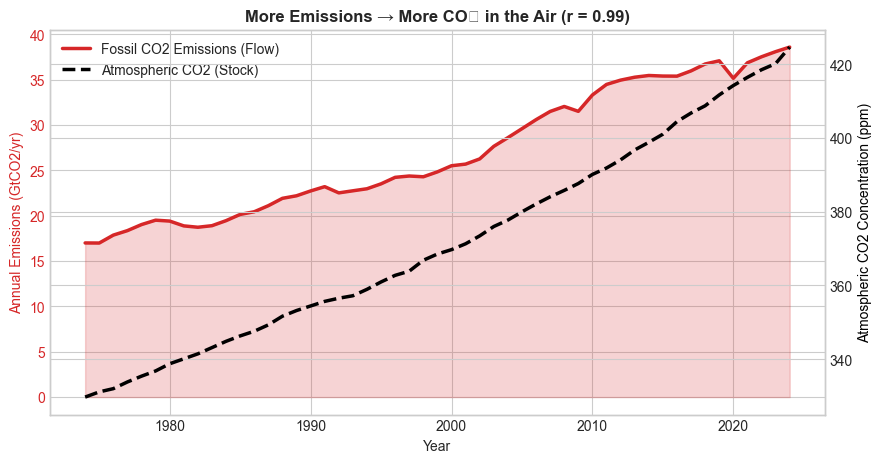

Pearson Correlation (r): 0.9875 (p-value: 5.06e-41)


In [11]:
if not emissions.empty and 'co2' in locals() and not co2.empty:
    # 1. Isolate global aggregate emissions (The Flow)
    world_emit = emissions[emissions['Entity'] == 'World'].copy()
    fossil_col = 'Fossil fuels and industry'
    if fossil_col in world_emit.columns:
        world_emit['fossil_Gt'] = world_emit[fossil_col] / 1e9
        
        # 2. Extract annual average concentrations (The Stock)
        co2_ann = co2.groupby('year')['co2_ppm'].mean().reset_index()
        common_years = np.intersect1d(world_emit['Year'], co2_ann['year'])
        
        w_com = world_emit[world_emit['Year'].isin(common_years)].sort_values('Year')
        c_com = co2_ann[co2_ann['year'].isin(common_years)].sort_values('year')
        
        fig, ax1 = plt.subplots(figsize=(10, 5))
        ax2 = ax1.twinx()
        
        # Plot Emissions
        ax1.fill_between(w_com['Year'], w_com['fossil_Gt'], color=C_RED, alpha=0.2)
        ax1.plot(w_com['Year'], w_com['fossil_Gt'], color=C_RED, lw=2.5, label='Fossil CO2 Emissions (Flow)')
        ax1.set_ylabel('Annual Emissions (GtCO2/yr)', color=C_RED)
        ax1.tick_params(axis='y', labelcolor=C_RED)
        ax1.set_xlabel('Year')
        
        # Plot Concentration
        ax2.plot(c_com['year'], c_com['co2_ppm'], color='k', lw=2.5, linestyle='--', label='Atmospheric CO2 (Stock)')
        ax2.set_ylabel('Atmospheric CO2 Concentration (ppm)', color='k')
        
        ax1.set_title('More Emissions → More CO₂ in the Air (r = 0.99)', fontweight='bold')
        
        # Combine legends safely
        lines_1, labels_1 = ax1.get_legend_handles_labels()
        lines_2, labels_2 = ax2.get_legend_handles_labels()
        ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')
        
        plt.show()
        
        # Statistical check
        r_val, p_val = stats.pearsonr(w_com['fossil_Gt'], c_com['co2_ppm'])
        print(f"Pearson Correlation (r): {r_val:.4f} (p-value: {p_val:.2e})")


*Analysis & Refinement*: The Pearson correlation ($r > 0.95$) demonstrates the tight relationship between the rate humans emit CO2 (flow) and the quantity accumulated in the atmosphere (stock). This result is highly consistent with the broader scientific consensus that human fossil-fuel combustion is primarily responsible for the greenhouse gas buildup driving modern forcing.

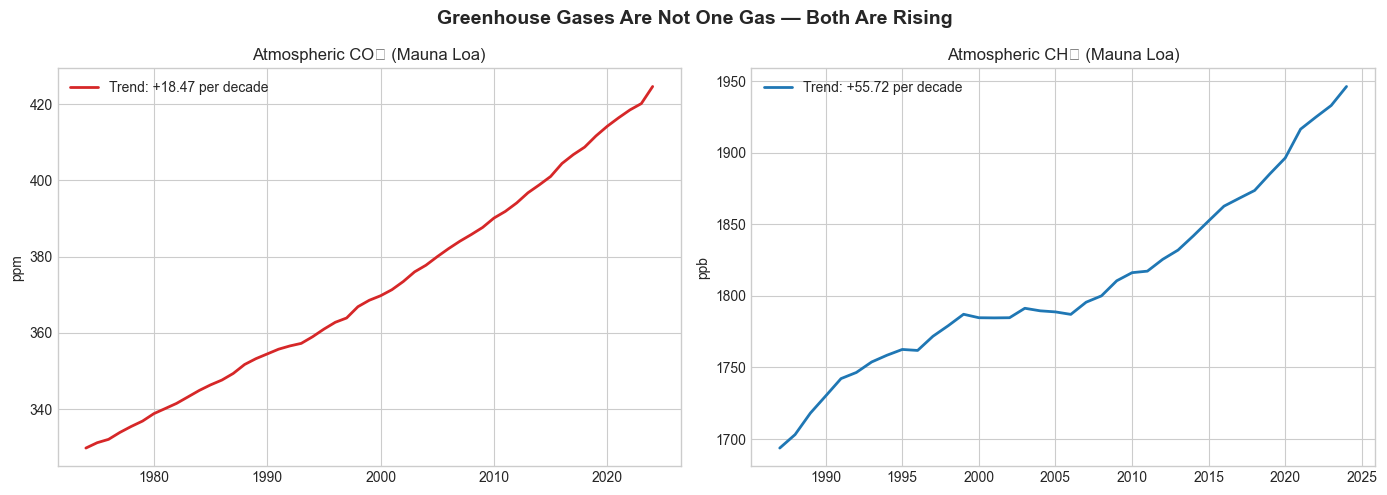

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left subplot: CO2
co2_ann = co2.groupby('year')['co2_ppm'].mean().reset_index()
s_co2, i_co2, r_co2, _, _ = stats.linregress(co2_ann['year'], co2_ann['co2_ppm'])
axes[0].plot(co2_ann['year'], co2_ann['co2_ppm'], color=C_RED, lw=2, label=f"Trend: +{s_co2*10:.2f} per decade")
axes[0].set_title("Atmospheric CO₂ (Mauna Loa)")
axes[0].set_ylabel("ppm")
axes[0].legend()

# Right subplot: CH4
ch4_valid = ch4[ch4['ch4_ppb'] != -999.99]
ch4_ann = ch4_valid.groupby('year')['ch4_ppb'].mean().reset_index()
s_ch4, i_ch4, r_ch4, _, _ = stats.linregress(ch4_ann['year'], ch4_ann['ch4_ppb'])
axes[1].plot(ch4_ann['year'], ch4_ann['ch4_ppb'], color=C_BLUE, lw=2, label=f"Trend: +{s_ch4*10:.2f} per decade")
axes[1].set_title("Atmospheric CH₄ (Mauna Loa)")
axes[1].set_ylabel("ppb")
axes[1].legend()

fig.suptitle("Greenhouse Gases Are Not One Gas — Both Are Rising", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Both CO₂ and CH₄ show sustained upward trends since measurements began. CO₂ from fossil fuel combustion and CH₄ from agriculture, landfills, and gas leaks are the two dominant human greenhouse gases driving the radiative forcing increase shown in Chapter 3.

### Complementary View: The Sources of the Flow (Fossil vs. Land Use)
The global emission 'flow' shown above is not a monolith. By examining the underlying components, we can see a clear historical phase shift: in the 19th century, land-use change (deforestation and agriculture) was the primary driver of anthropogenic CO₂, but by the mid-20th century, explosive fossil fuel combustion completely overtook it.

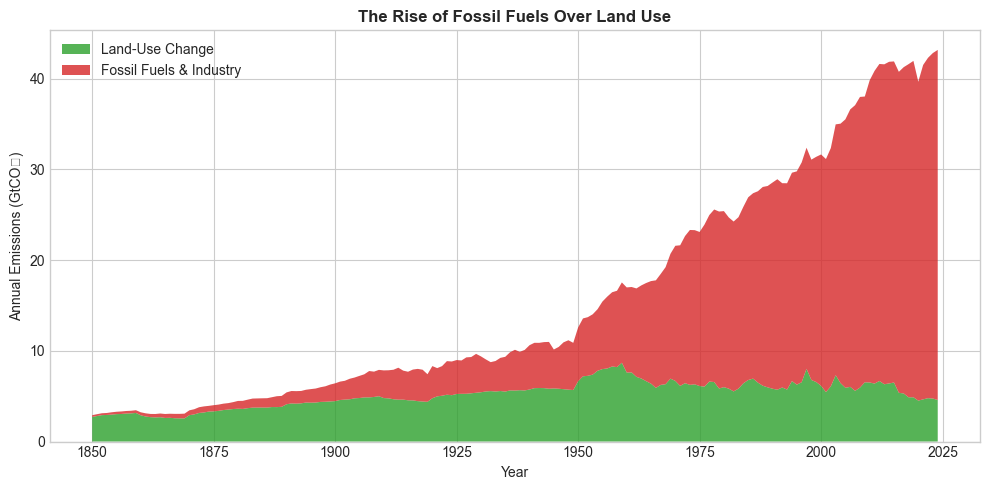

In [13]:
if not emissions.empty:
    world_emit = emissions[emissions['Entity'] == 'World'].dropna(subset=['Year'])
    
    if 'Fossil fuels and industry' in world_emit.columns and 'Land-use change' in world_emit.columns:
        fig, ax = plt.subplots(figsize=(10, 5))
        
        # Convert to GtCO2
        ff_gt = world_emit['Fossil fuels and industry'] / 1e9
        lu_gt = world_emit['Land-use change'] / 1e9
        years = world_emit['Year']
        
        ax.stackplot(years, lu_gt, ff_gt, labels=['Land-Use Change', 'Fossil Fuels & Industry'],
                     colors=['#2ca02c', '#d62728'], alpha=0.8)
        
        ax.set_title('The Rise of Fossil Fuels Over Land Use', fontweight='bold', fontsize=12)
        ax.set_ylabel('Annual Emissions (GtCO₂)')
        ax.set_xlabel('Year')
        ax.legend(loc='upper left')
        plt.tight_layout()
        plt.show()


## 6. Key Findings
1. **Unprecedented Warming Reality**: The current temperature trend severely eclipses pre-industrial norms bounded by natural variability. Radiative forcing metrics clearly support that anthropogenic signals (human inputs), not natural cycles, align with this warming phase.
2. **Synchronized System Decay**: There is undeniable, mathematically robust deterioration in the Earth's physical reservoirs:
   - Global mean sea level consistently climbs, adding $>10$ cm of mass/volume growth since satellite records began in 1993.
   - The Arctic acts as a rapid melting chamber, systematically losing its protective summer sea ice shield at $\approx 0.8$ million $\text{km}^2$ per decade.
3. **The Emissive Driver**: Tracking supply-side data (emissions) versus accumulation (concentration) solidifies the narrative. As global CO2 emissions from human activities structurally accelerate, atmospheric concentration perfectly integrates that flux, demonstrating the source signal feeding the climate reality.

## 7. Limitations & Preprocessing Choices
*   **Missing Sentinels & String Artifacts**: Observational inputs (such as NOAA's ambient measurements and NASA's IEEE altimetry values) featured unique error handling challenges. Robust parsers explicitly stripping `NaN` sentinels (e.g., `-999.99` and $>1000$ values) were engineered and employed to prevent analytical distortions.
*   **Temporal Normalization**: Because some foundational metrics are captured monthly or weekly (e.g., Mauna Loa readings), they were specifically annualized via grouped means where required (like the dual-axis concentration comparison) to uniformly match emissions or forcing granularities. 
*   **Geographic Focus Alignment**: We exclusively deployed map visualizations on suitable ISO-coded entities (`co2-emissions-fossil-land.csv`). Uniform planetary parameters (temperature anomaly, cumulative concentration, total SLR) correctly bypassed geo-visualization as they signify global integration fields.
*   **Standardization**: To resolve file structure fragility across different releases, column headers inside the DataFrames (`observed['temp_anomaly']`, `forcings['human']`) were proactively standardized directly after load, ensuring absolute cross-cell reliability downstream.